# Presentation Visualizations — AI4ALL Group 05A "Agent-EYE"

Reproducible code for the five charts used on the **Data Visualizations** slides
(11–12) of the deck. Every chart is generated from
`cleaned_agent_security_risk_scores.csv` (the cleaned dataset committed to the repo).

**How to run:** run all cells top to bottom. Each chart is shown inline *and* saved as a
high-resolution PNG in `./visualizations/` (transparent background, so it drops straight onto
the pink slides).

**Requirements:** `pandas`, `numpy`, `matplotlib`.


In [1]:
# ------------------------------------------------------------------
# Setup: imports, data, shared palette + styling
# ------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the CLEANED dataset (vendored in data/ - see DATA_NOTICE.md).
df = pd.read_csv("data/cleaned_agent_security_risk_scores.csv")
print("rows, cols:", df.shape)

# Where PNGs are written (created if missing).
OUT = "visualizations"
os.makedirs(OUT, exist_ok=True)

# --- Palette (colorblind-aware defaults) ---
INK   = "#0b0b0b"   # primary text
INK2  = "#52514e"   # secondary text
MUTED = "#898781"   # axes / footnotes
GRID  = "#d9b9c6"   # gridlines (tuned to sit softly on the pink slide)
BLUE  = "#2a78d6"   # single-hue magnitude
RED   = "#e34948"   # negative pole (diverging)
# Access-decision status colors: Allowed=green, Needs-Human=amber, Blocked=red
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 12, "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "figure.dpi": 120, "savefig.dpi": 200,
})

def style(ax):
    """Recessive chrome: drop top/right spines, soften the rest, no tick marks."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED); ax.spines[s].set_linewidth(1)
    ax.tick_params(length=0)

def save(fig, name):
    fig.savefig(f"{OUT}/{name}.png", transparent=True, bbox_inches="tight", pad_inches=0.15)

# Consistent decision order + colors used across charts
ORDER = ["Blocked", "Allowed", "Needs_Human_Approval"]
DCOL  = {"Blocked": CRIT, "Allowed": GOOD, "Needs_Human_Approval": WARN}


rows, cols: (2200, 15)


## 1. Access decisions are highly imbalanced
Blocked dominates the dataset — worth flagging because it affects every downstream model
(hence the stratified train/test split).

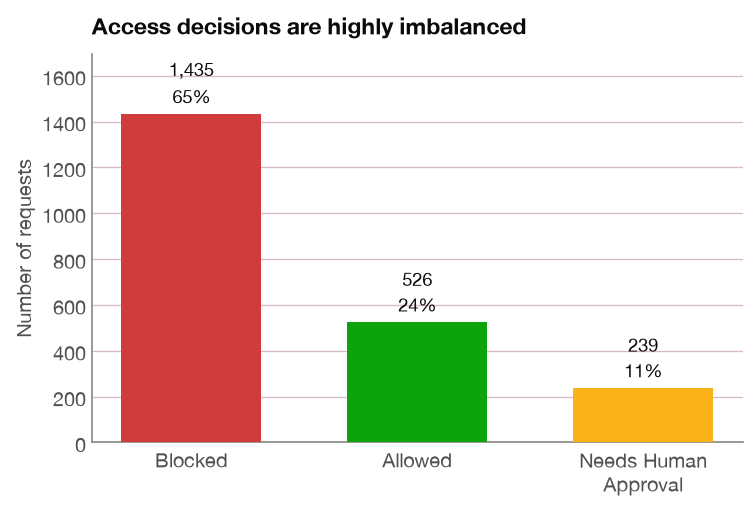

In [2]:
counts = df["access_decision"].value_counts().reindex(ORDER)

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(range(len(ORDER)), counts.values,
              color=[DCOL[o] for o in ORDER], width=0.62, zorder=3)
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(["Blocked", "Allowed", "Needs Human\nApproval"])
ax.set_ylabel("Number of requests")
ax.set_title("Access decisions are highly imbalanced",
             fontsize=14, fontweight="bold", pad=12, loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 18, f"{v:,}\n{v/len(df)*100:.0f}%",
            ha="center", va="bottom", fontsize=11, color=INK, linespacing=1.2)
ax.set_ylim(0, counts.max()*1.18); style(ax)
save(fig, "01_access_decision_distribution")
plt.show()


## 2. Risk scores span the full range
The target `action_risk_score` is spread across 0–100 (mean ≈ 55) with a spike at the top —
not concentrated in one bucket.

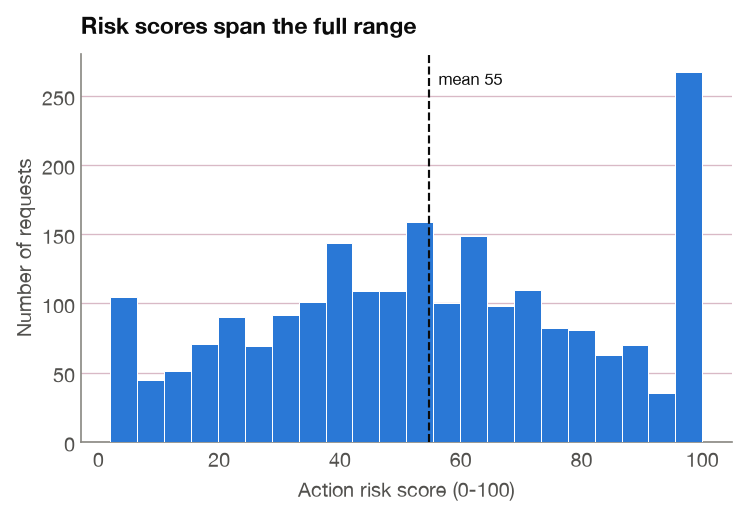

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(df["action_risk_score"], bins=22, color=BLUE,
        edgecolor="white", linewidth=0.6, zorder=3)
ax.set_xlabel("Action risk score (0-100)")
ax.set_ylabel("Number of requests")
ax.set_title("Risk scores span the full range",
             fontsize=14, fontweight="bold", pad=12, loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
mean = df["action_risk_score"].mean()
ax.axvline(mean, color=INK, linestyle="--", linewidth=1.3, zorder=4)
ax.text(mean + 1.5, ax.get_ylim()[1]*0.92, f"mean {mean:.0f}", color=INK, fontsize=10)
style(ax)
save(fig, "02_risk_score_distribution")
plt.show()


## 3. Risk score is similar across agent roles
Average score by role sits in a narrow 51–60 band — evidence of **little role-based bias**
in how the scorer treats different agents.

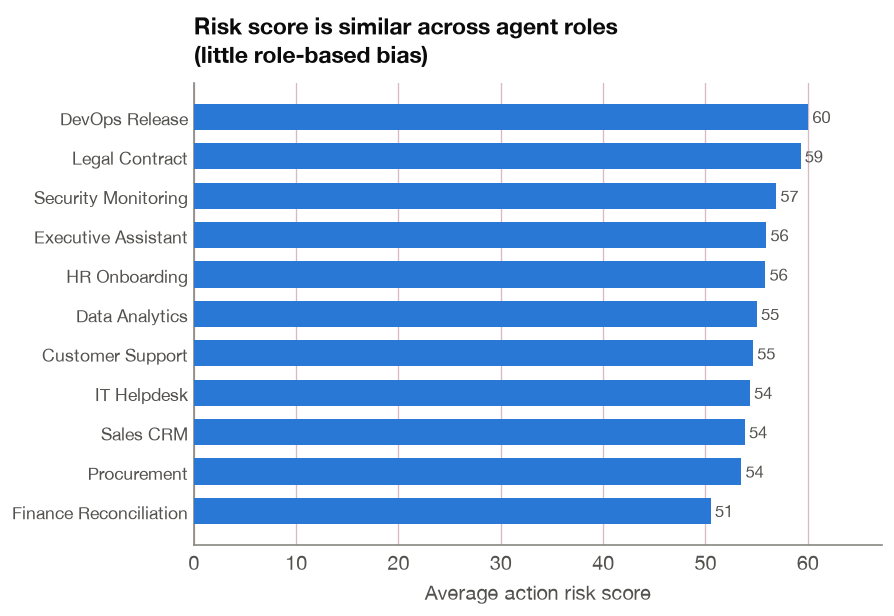

In [4]:
def nice_role(r):
    r = r.replace("_", " ").replace(" agent", "")
    fix = {"hr": "HR", "it": "IT", "crm": "CRM", "devops": "DevOps"}
    return " ".join(fix.get(w, w.title()) for w in r.split())

avg = df.groupby("agent_role")["action_risk_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7.4, 5))
bars = ax.barh(range(len(avg)), avg.values, color=BLUE, height=0.66, zorder=3)
ax.set_yticks(range(len(avg)))
ax.set_yticklabels([nice_role(r) for r in avg.index], fontsize=10.5)
ax.set_xlabel("Average action risk score")
ax.set_title("Risk score is similar across agent roles\n(little role-based bias)",
             fontsize=14, fontweight="bold", pad=12, loc="left")
ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for b, v in zip(bars, avg.values):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, f"{v:.0f}",
            va="center", fontsize=10, color=INK2)
ax.set_xlim(0, avg.max()*1.12); style(ax)
save(fig, "03_avg_risk_by_agent_role")
plt.show()


## 4. What drives the risk score
Correlation of each numeric feature with `action_risk_score`. Data-exfiltration risk and
resource sensitivity push scores **up**; permission match pulls them **down**.

> **Note:** `human_approval_required` is deliberately excluded — it is decided *after* the
> score (downstream / leaky), so treating it as a driver would be causally backwards.

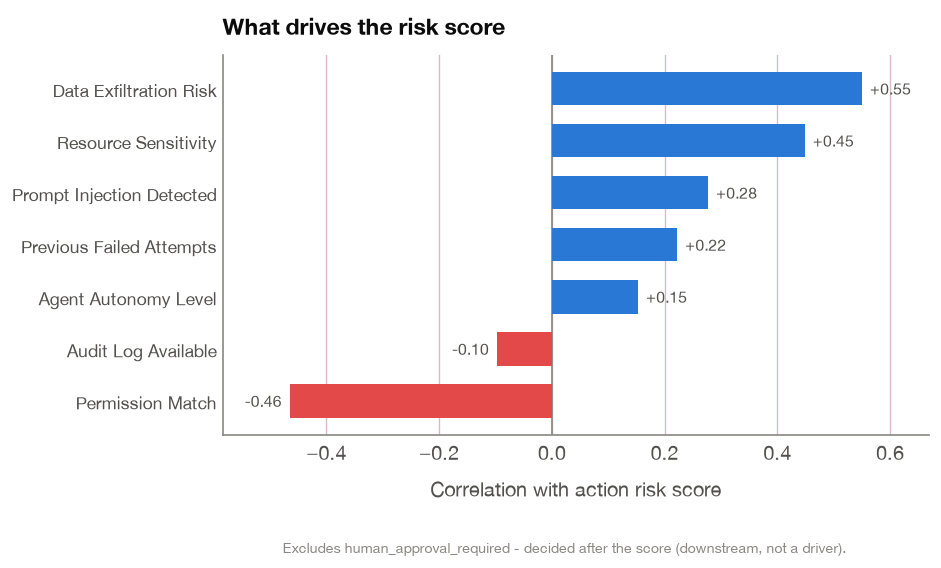

In [5]:
num = ["permission_match", "data_exfiltration_risk", "resource_sensitivity",
       "prompt_injection_detected", "previous_failed_attempts",
       "agent_autonomy_level", "audit_log_available"]  # excludes human_approval_required (leaky)

corr = (df[num + ["action_risk_score"]].corr()["action_risk_score"]
          .drop("action_risk_score").sort_values())
colors = [BLUE if v >= 0 else RED for v in corr.values]

fig, ax = plt.subplots(figsize=(7.6, 4.8))
bars = ax.barh(range(len(corr)), corr.values, color=colors, height=0.64, zorder=3)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels([c.replace("_", " ").title() for c in corr.index], fontsize=10.5)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel("Correlation with action risk score", labelpad=8)
ax.set_title("What drives the risk score",
             fontsize=14, fontweight="bold", pad=12, loc="left")
ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for b, v in zip(bars, corr.values):
    ax.text(v + (0.015 if v >= 0 else -0.015), b.get_y() + b.get_height()/2,
            f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right",
            fontsize=9.5, color=INK2)
ax.set_xlim(corr.min() - 0.12, corr.max() + 0.12); style(ax)
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.015,
         "Excludes human_approval_required - decided after the score (downstream, not a driver).",
         ha="center", fontsize=8.5, color=MUTED)
save(fig, "04_feature_correlation")
plt.show()


## 5. Prompt-injection requests are almost all Blocked
Prompt injection is rare (123 of 2,200), so we compare the **share** of decisions within each
group. When injection is detected, ~99% of requests are Blocked.

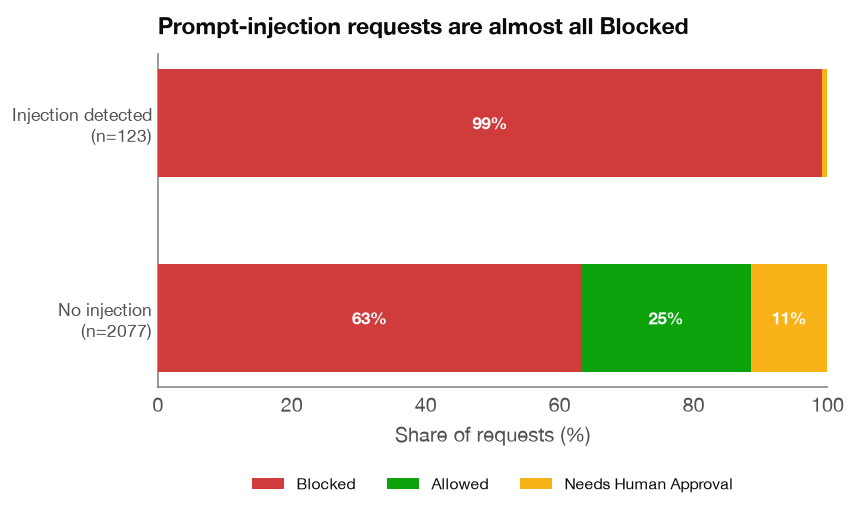

In [6]:
ct = (pd.crosstab(df["prompt_injection_detected"], df["access_decision"],
                  normalize="index")[ORDER] * 100)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ypos = [0, 1]; left = np.zeros(2)
labels = {"Needs_Human_Approval": "Needs Human Approval"}
for o in ORDER:
    vals = ct[o].values
    ax.barh(ypos, vals, left=left, color=DCOL[o], height=0.55,
            label=labels.get(o, o), zorder=3)
    for y, v, l in zip(ypos, vals, left):
        if v > 6:
            ax.text(l + v/2, y, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontsize=10, fontweight="bold")
    left += vals
n0 = int((df["prompt_injection_detected"] == 0).sum())
n1 = int((df["prompt_injection_detected"] == 1).sum())
ax.set_yticks(ypos)
ax.set_yticklabels([f"No injection\n(n={n0})", f"Injection detected\n(n={n1})"], fontsize=10.5)
ax.set_xlabel("Share of requests (%)"); ax.set_xlim(0, 100)
ax.set_title("Prompt-injection requests are almost all Blocked",
             fontsize=14, fontweight="bold", pad=12, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9.5)
style(ax)
save(fig, "05_injection_vs_decision")
plt.show()


---
All five PNGs are now in `./slide-charts/`. Re-run any cell to regenerate that chart.